# 📊 EDA: Employee Attrition & Retention Factors

This notebook analyzes key factors driving employee churn: compensation, overtime, commute distance, and job satisfaction.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Configure paths
BASE_DIR = Path('..').resolve()
sys.path.append(str(BASE_DIR))
from app.backend.config import *

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

### 1. Load Processed Attrition Dataset

In [4]:
df = pd.read_csv(DATA_PROCESSED_DIR / 'processed_attrition.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1470, 40)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Numeric,OverTime_Numeric,TotalSatisfaction,IncomePerYearExperience,TenureToAgeRatio,RoleTenureRatio,ManagerTenureRatio,PromotionStagnation
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,0,5,1,1,8,665.888889,0.146341,0.571429,0.714286,0.000000
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,1,7,0,0,12,466.363636,0.204082,0.636364,0.636364,0.090909
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,0,0,1,1,12,261.250000,0.000000,0.000000,0.000000,0.000000
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,0,0,1,13,323.222222,0.242424,0.777778,0.000000,0.333333
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,2,2,0,0,10,495.428571,0.074074,0.666667,0.666667,0.666667


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeNumber            1470 non-null   int64  
 9   EnvironmentSatisfaction   1470 non-null   int64  
 10  Gender                    1470 non-null   object 
 11  HourlyRate                1470 non-null   int64  
 12  JobInvolvement            1470 non-null   int64  
 13  JobLevel                  1470 non-null   int64  
 14  JobRole 

### 2. Overall Attrition Rate & Distribution

           Count  Percentage (%)
Attrition                       
No          1233           83.88
Yes          237           16.12


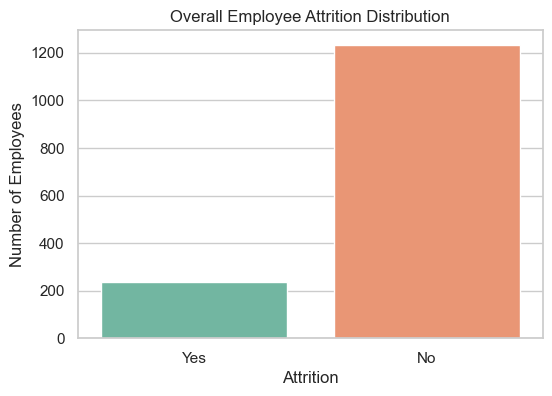

In [3]:
att_counts = df['Attrition'].value_counts()
att_pct = df['Attrition'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': att_counts, 'Percentage (%)': att_pct.round(2)}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='Set2')
plt.title('Overall Employee Attrition Distribution')
plt.ylabel('Number of Employees')
plt.show()

### 3. Impact of Overtime and Monthly Income on Attrition

C:\Users\hs264\AppData\Local\Temp\ipykernel_20096\3254161013.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1], palette='Set2')


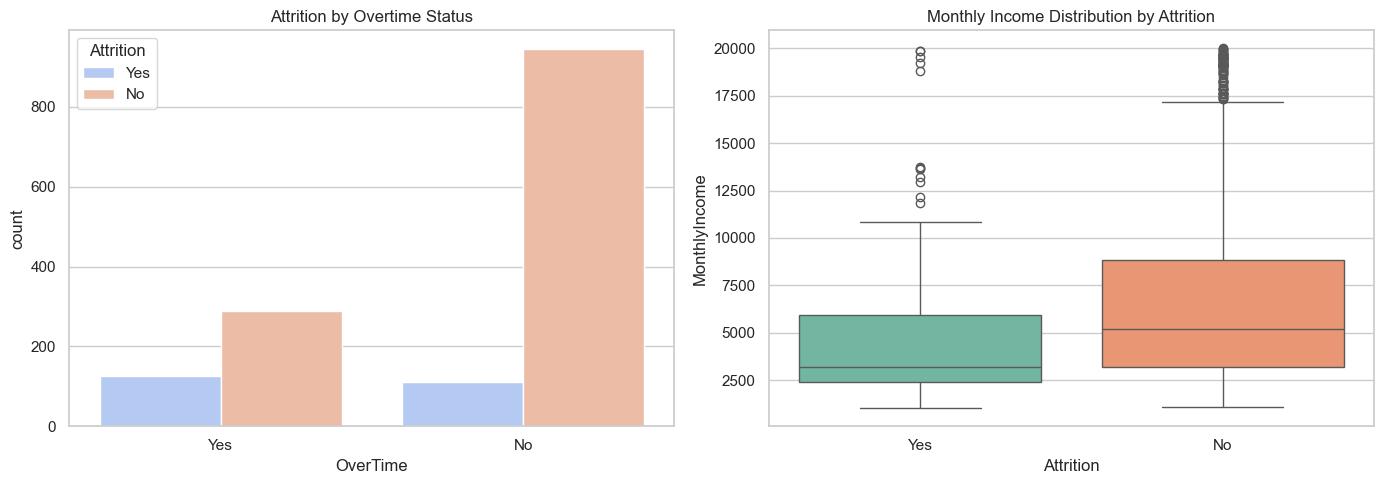

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OverTime vs Attrition
sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0], palette='coolwarm')
axes[0].set_title('Attrition by Overtime Status')

# Monthly Income vs Attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1], palette='Set2')
axes[1].set_title('Monthly Income Distribution by Attrition')

plt.tight_layout()
plt.show()

### 4. Department & Job Role Wise Attrition

C:\Users\hs264\AppData\Local\Temp\ipykernel_20096\3822474239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=role_att.values, y=role_att.index, palette='Reds_r')


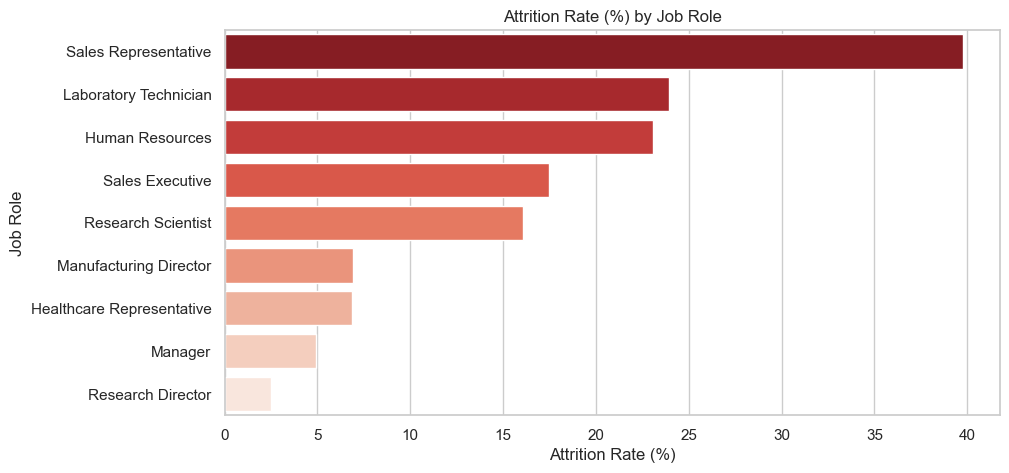

In [5]:
role_att = df.groupby('JobRole')['Attrition_Numeric'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=role_att.values, y=role_att.index, palette='Reds_r')
plt.title('Attrition Rate (%) by Job Role')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')
plt.show()

### 5. Correlation Heatmap of Retention Drivers

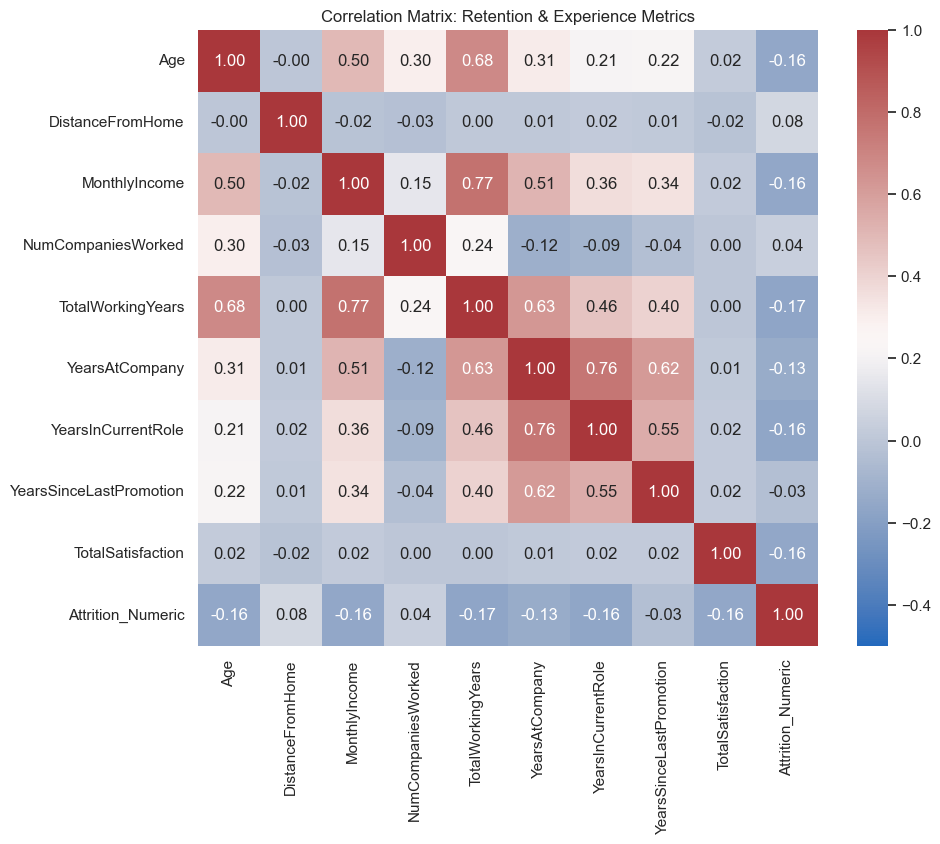

In [6]:
key_num_cols = [
    'Age', 'DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
    'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'TotalSatisfaction', 'Attrition_Numeric'
]
corr = df[key_num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', vmin=-0.5, vmax=1.0, cbar=True)
plt.title('Correlation Matrix: Retention & Experience Metrics')
plt.show()